# **Leads conversion prediction system.**

# **Problem Statement**

## Business Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62 bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert

## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.

* **ID**: ID of the lead.
* **age**: Age of the lead.
* **current_occupation**: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'.
* **first_interaction**: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'.
* **profile_completed**: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%).
* **website_visits**: How many times has a lead visited the website.
* **time_spent_on_website**: Total time spent on the website in seconds.
* **page_views_per_visit**: Average number of pages on the website viewed during the visits.
* **last_activity**: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc.
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc.
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc.

* **print_media_type1**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* **print_media_type2**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* **digital_media**: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* **educational_channels**: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* **referral**: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* **status**: Flag indicating whether the lead was converted to a paid customer or not.


# **Installing and Importing the Necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

In [101]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [4]:
# loadGoogle Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
learn = pd.read_csv("/content/drive/MyDrive/ExtraLearn.csv") #read the data

In [6]:
# copying data to another variable to avoid any changes to original data
data = learn.copy()

## Overview of the dataset

### View the first and last 5 rows of the dataset

In [7]:
data.head() #display the first 5 rows of the dataset

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [8]:
data.tail() #display the last 5 rows of the dataset

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


### Understand the shape of the dataset

In [9]:
data.shape #print the shape

(4612, 15)

### Check the data types of the columns for the dataset

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

### Dropping the duplicate values

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

### Dropping the unique values column

In [12]:
# checking the number of unique values
data["ID"].nunique()

4612

**Let's drop the ID column first before we proceed forward**.

In [13]:
data = data.drop(["ID"], axis=1) #drop the column named 'ID'

# **Exploratory Data Analysis**

**Let's check the statistical summary of the data.**

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [15]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
--------------------------------------------------
digital_media
No     4085
Yes     527
Name: count, dtype: int64
--------------------------------------------------
educational_channels
No     3907
Yes     705
Name

**The below functions need to be defined to carry out the EDA.**

In [16]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [17]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [18]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [19]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0])

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Observations on age

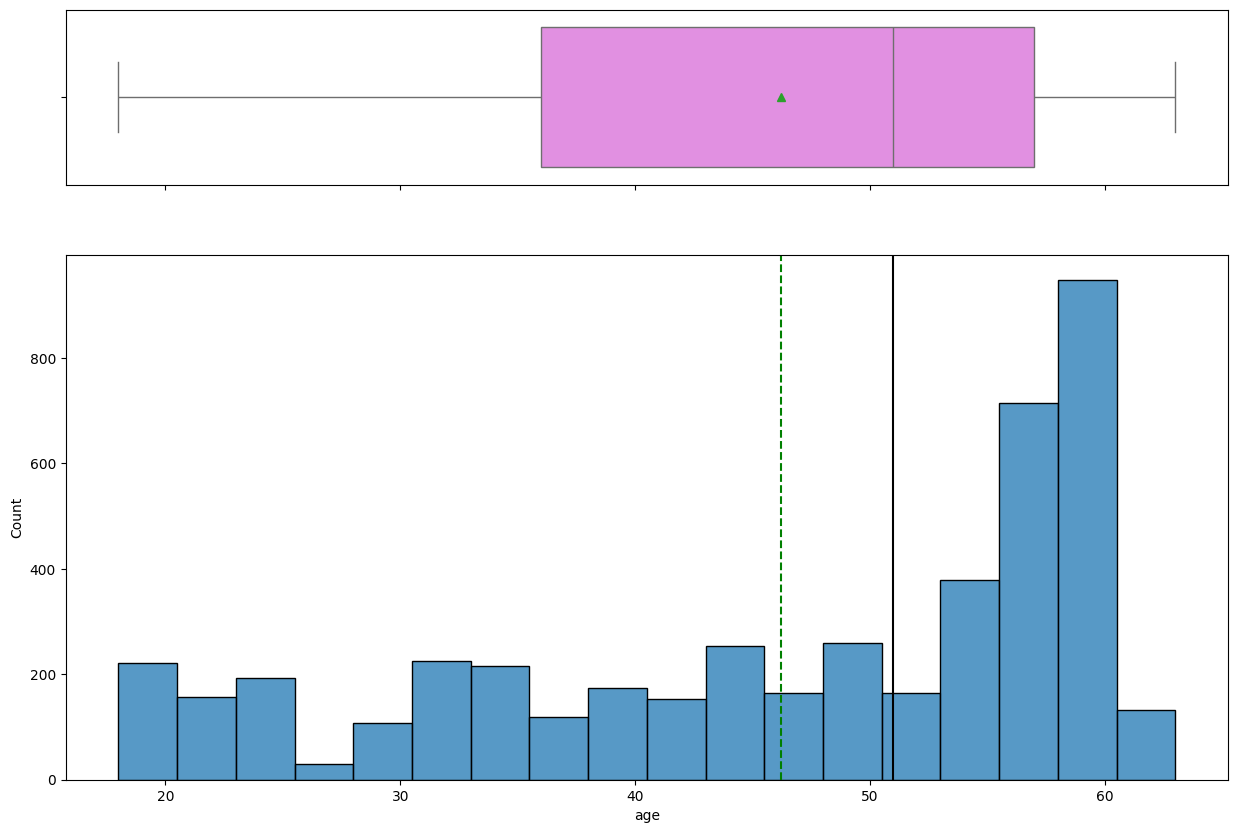

In [20]:
histogram_boxplot(data, "age")

#### Observations on website_visits

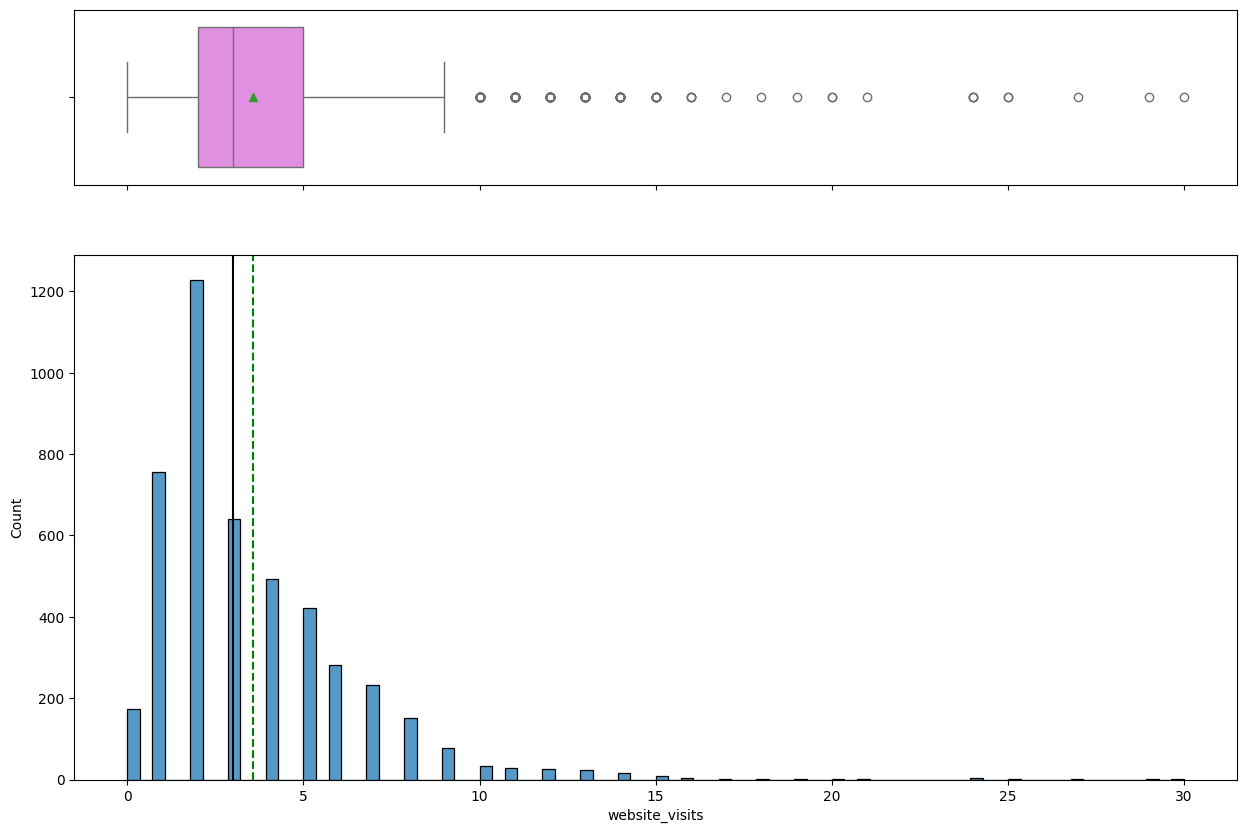

In [21]:
histogram_boxplot(data, "website_visits") #plot a histogram of the column named 'website_visits'

In [22]:
data[data["website_visits"] == 0].shape

(174, 14)

#### Observations on number of time_spent_on_website

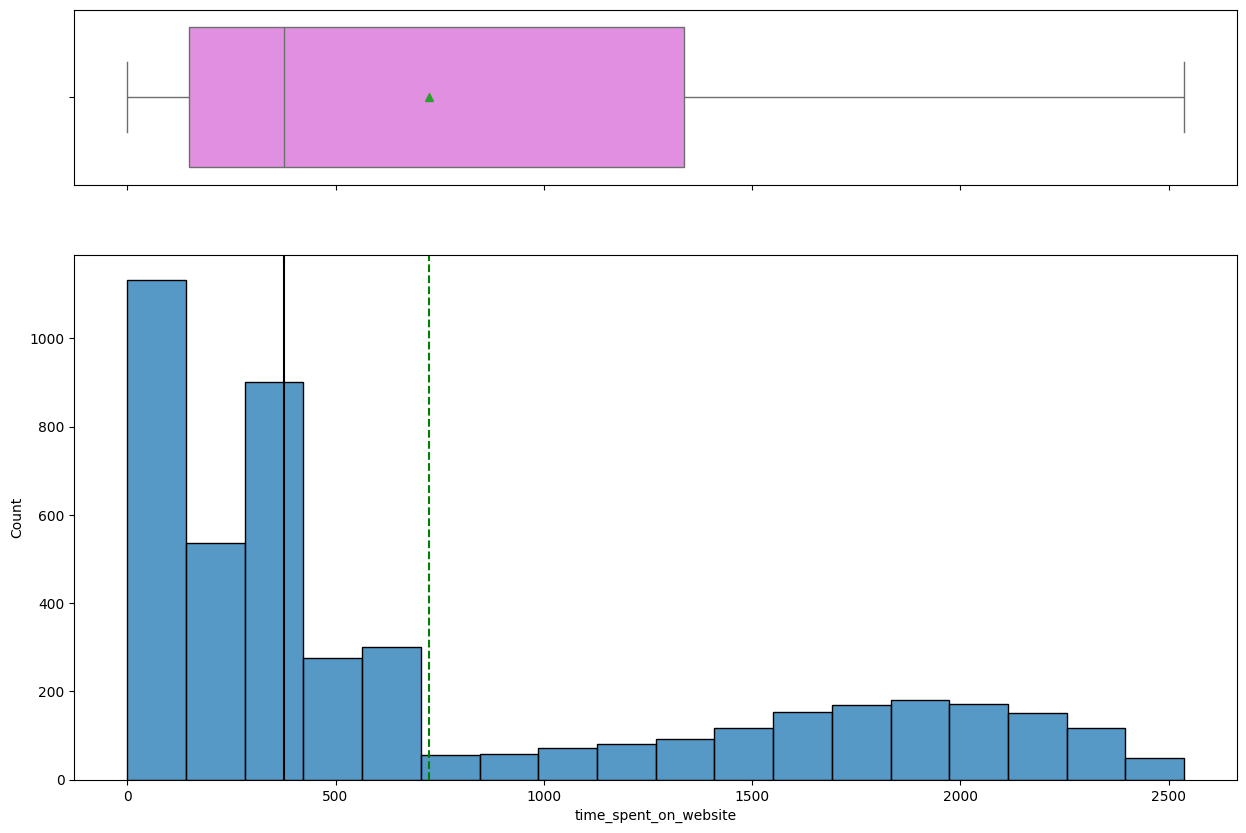

In [23]:
histogram_boxplot(data, "time_spent_on_website") #plot a histogram of the column named 'time_spent_on_website'

#### Observations on number of page_views_per_visit

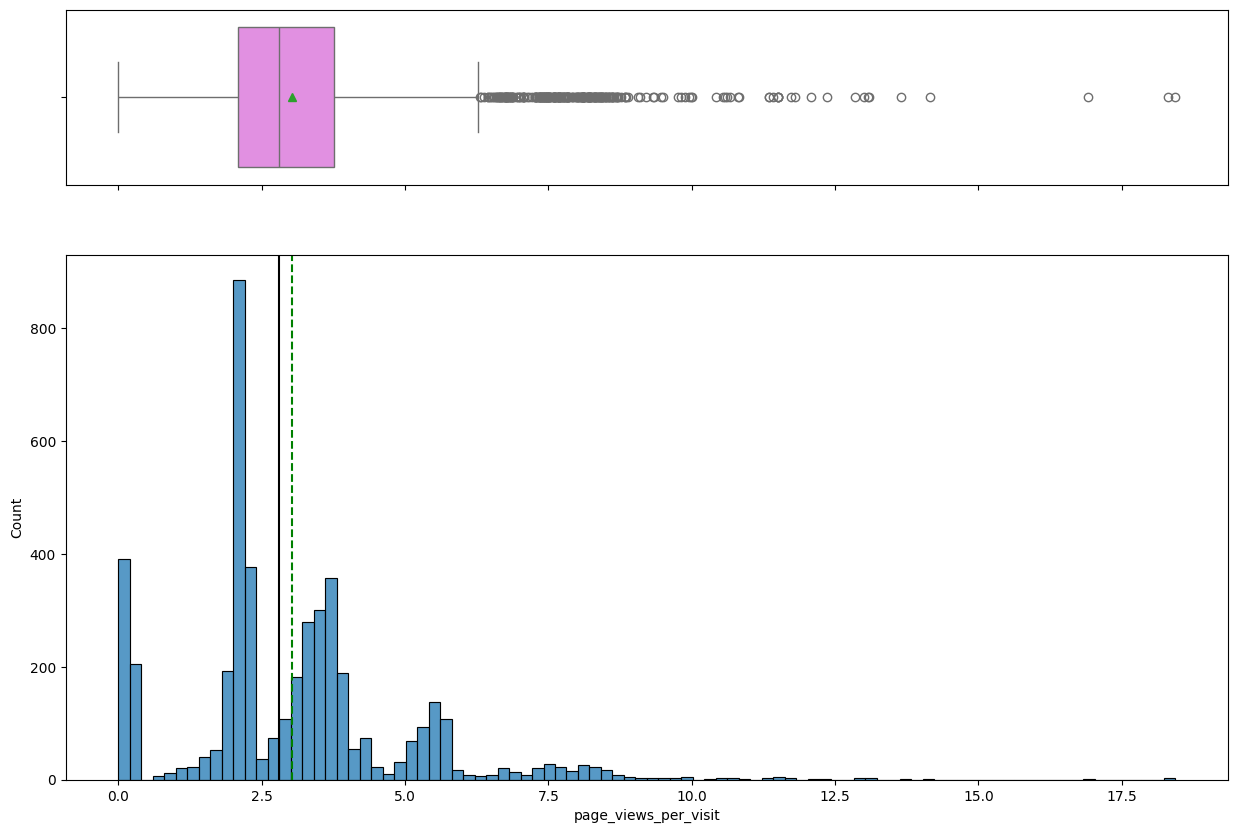

In [24]:
histogram_boxplot(data, "page_views_per_visit") #plot a histogram of the column named 'page_views_per_visit'

#### Observations on number of adults

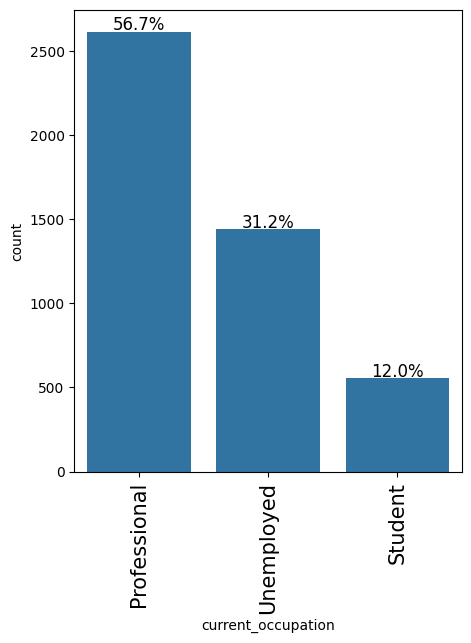

In [25]:
labeled_barplot(data, "current_occupation", perc=True)

#### Observations on first_interaction

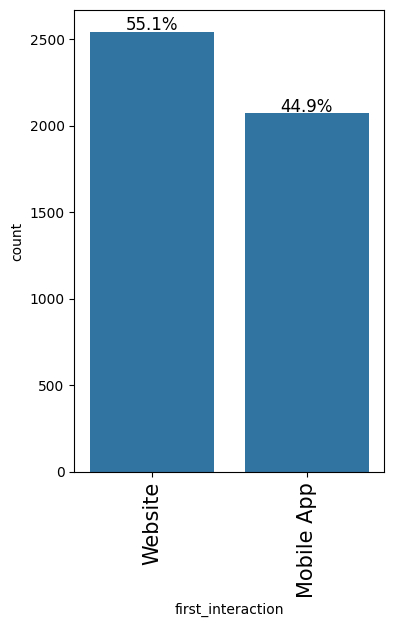

In [26]:
labeled_barplot(data, "first_interaction", perc=True) #labelled barplot of the column named 'first_interaction'

#### Observations on profile_completed

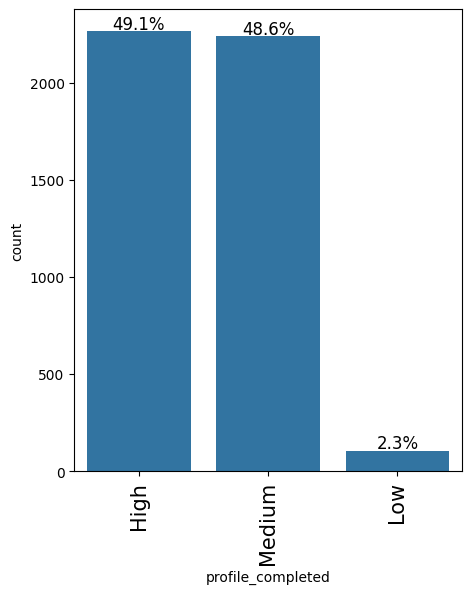

In [27]:
labeled_barplot(data, "profile_completed", perc=True) #labelled barplot of the column named 'profile_completed'

#### Observations on last_activity

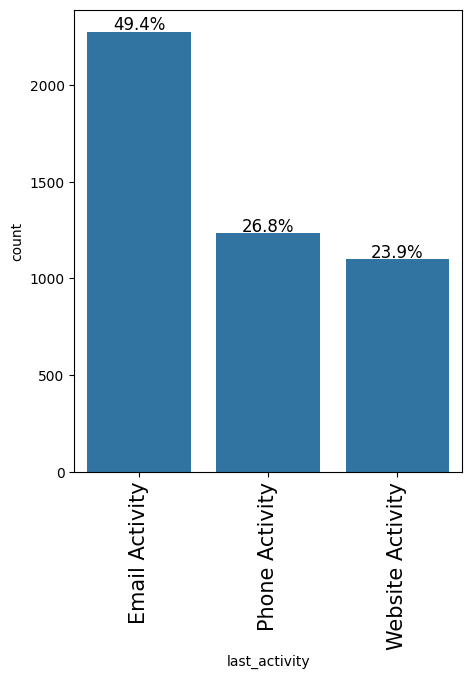

In [28]:
labeled_barplot(data, "last_activity", perc=True) #barplot of the column named 'last_activity'

#### Observations on print_media_type1

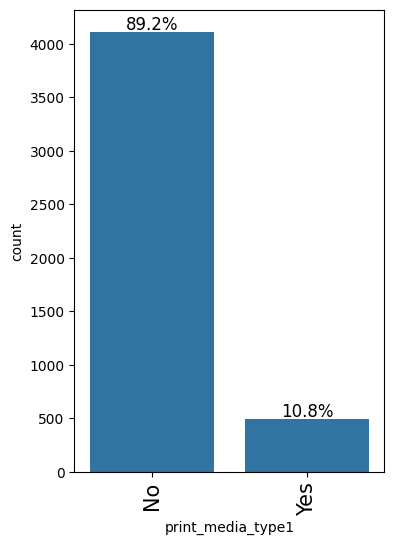

In [30]:
labeled_barplot(data, "print_media_type1", perc=True) #labelled barplot of the column named 'print_media_type1'

#### Observations on print_media_type2

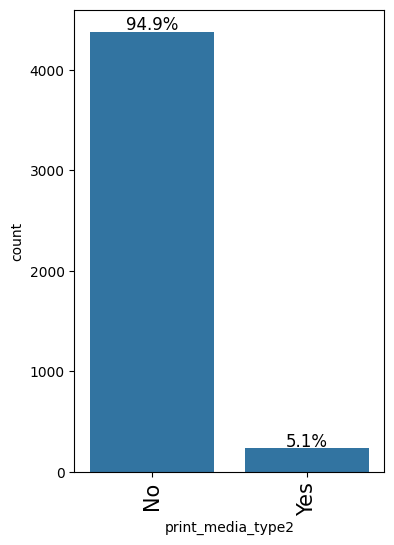

In [31]:
labeled_barplot(data, "print_media_type2", perc=True) # barplot of the column named 'print_media_type_2'

#### Observations on room type reserved

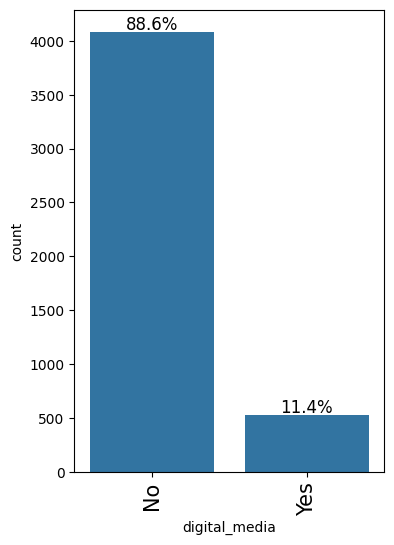

In [32]:
labeled_barplot(data, "digital_media", perc=True) #labelled barplot of the column named 'digital_media'

#### Observations on educational_channels

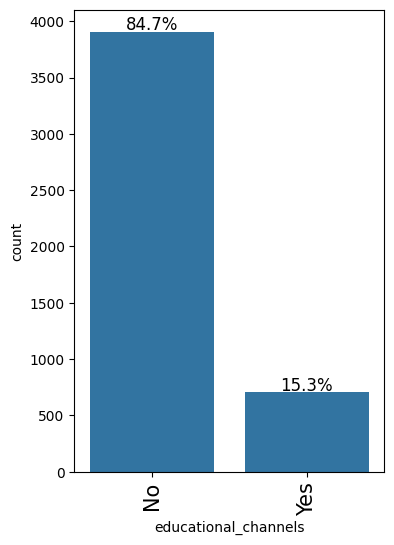

In [33]:
labeled_barplot(data, "educational_channels", perc=True) #labelled barplot of the column named 'educational_channels'

#### Observations on referral

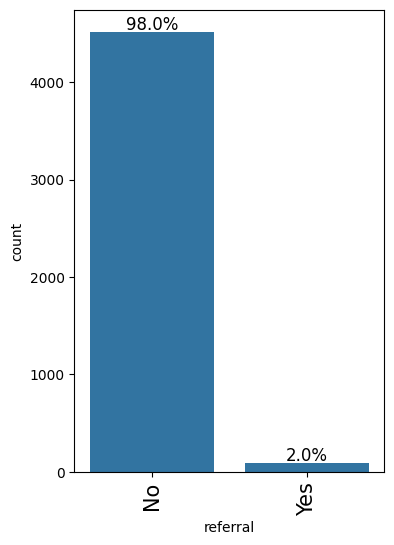

In [34]:
labeled_barplot(data, "referral", perc=True) #labelled barplot of the column named 'referral'

#### Observations on status

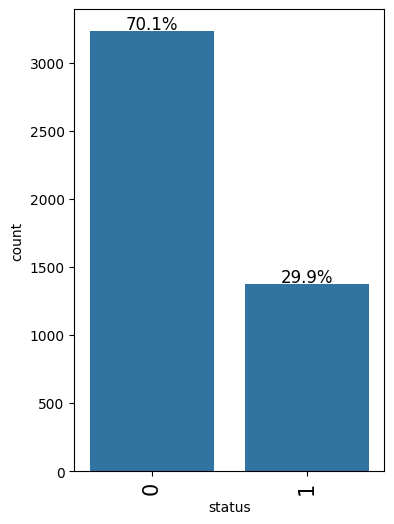

In [35]:
labeled_barplot(data, "status", perc=True) #labelled barplot of the column named 'status'

### Bivariate Analysis

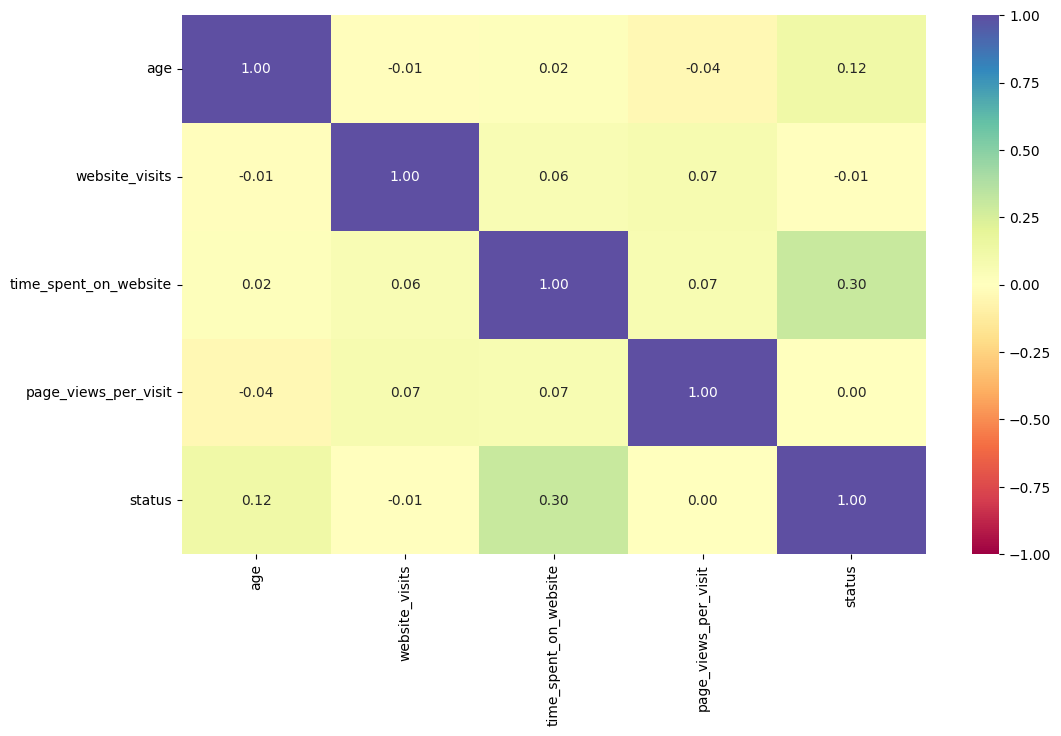

In [36]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Leads will have different expectations from the outcome of the course and the current occupation may play a key role for them to take the program. Let's analyze it**

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


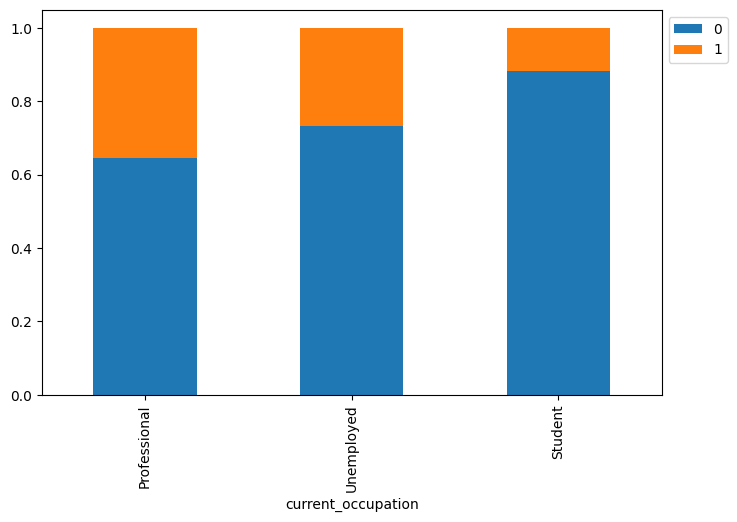

In [37]:
stacked_barplot(data, "current_occupation", "status")

**Age can be a good factor to differentiate between such leads**

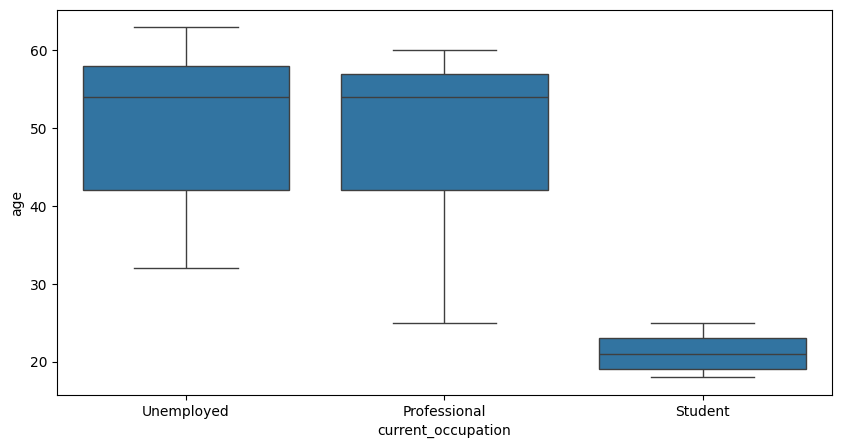

In [38]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data,x="current_occupation", y="age")
plt.show()

In [ ]:
data.groupby(["current_occupation"])["age"].describe()

**The company's first interaction with leads should be compelling and persuasive. Let's see if the channels of the first interaction have an impact on the conversion of leads**

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


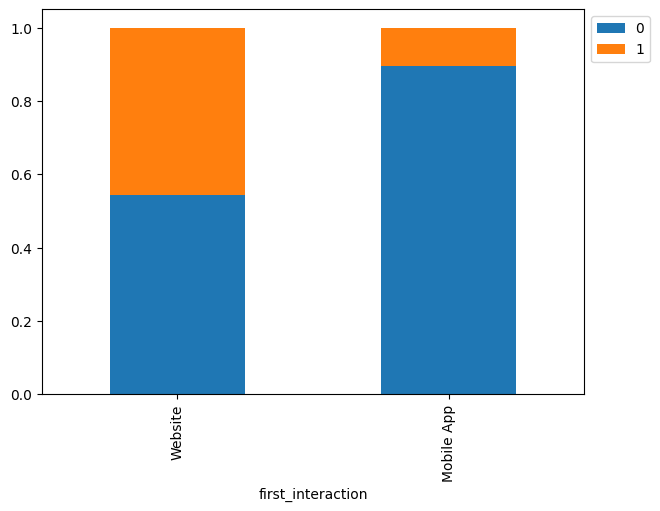

In [39]:
stacked_barplot(data, "first_interaction", "status") #barplot between first_interaction and status

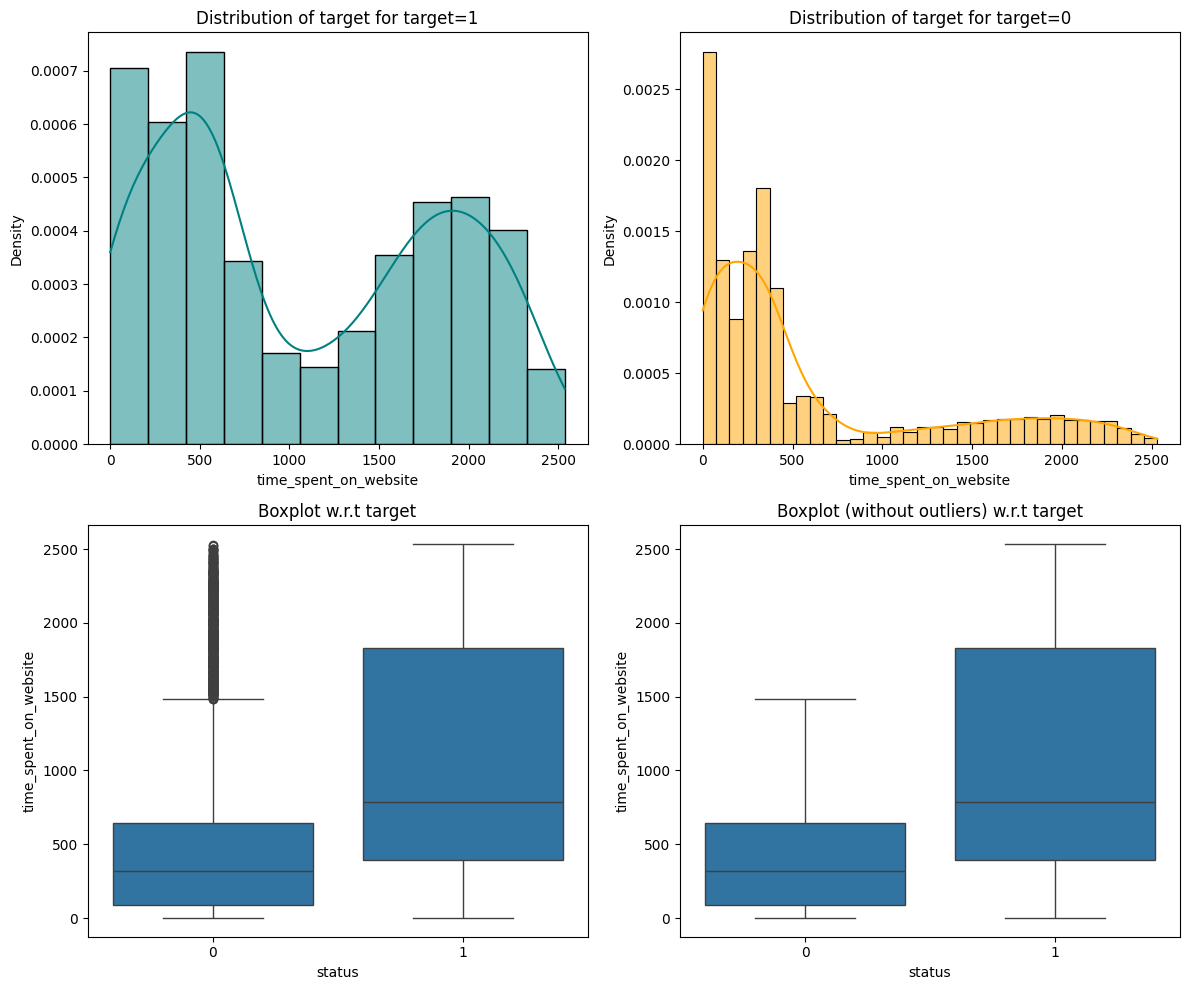

In [40]:
distribution_plot_wrt_target(data, "time_spent_on_website", "status")

In [41]:
# checking the median value
data.groupby(["status"])["time_spent_on_website"].median()

,time_spent_on_website
status,
0,317.0
1,789.0


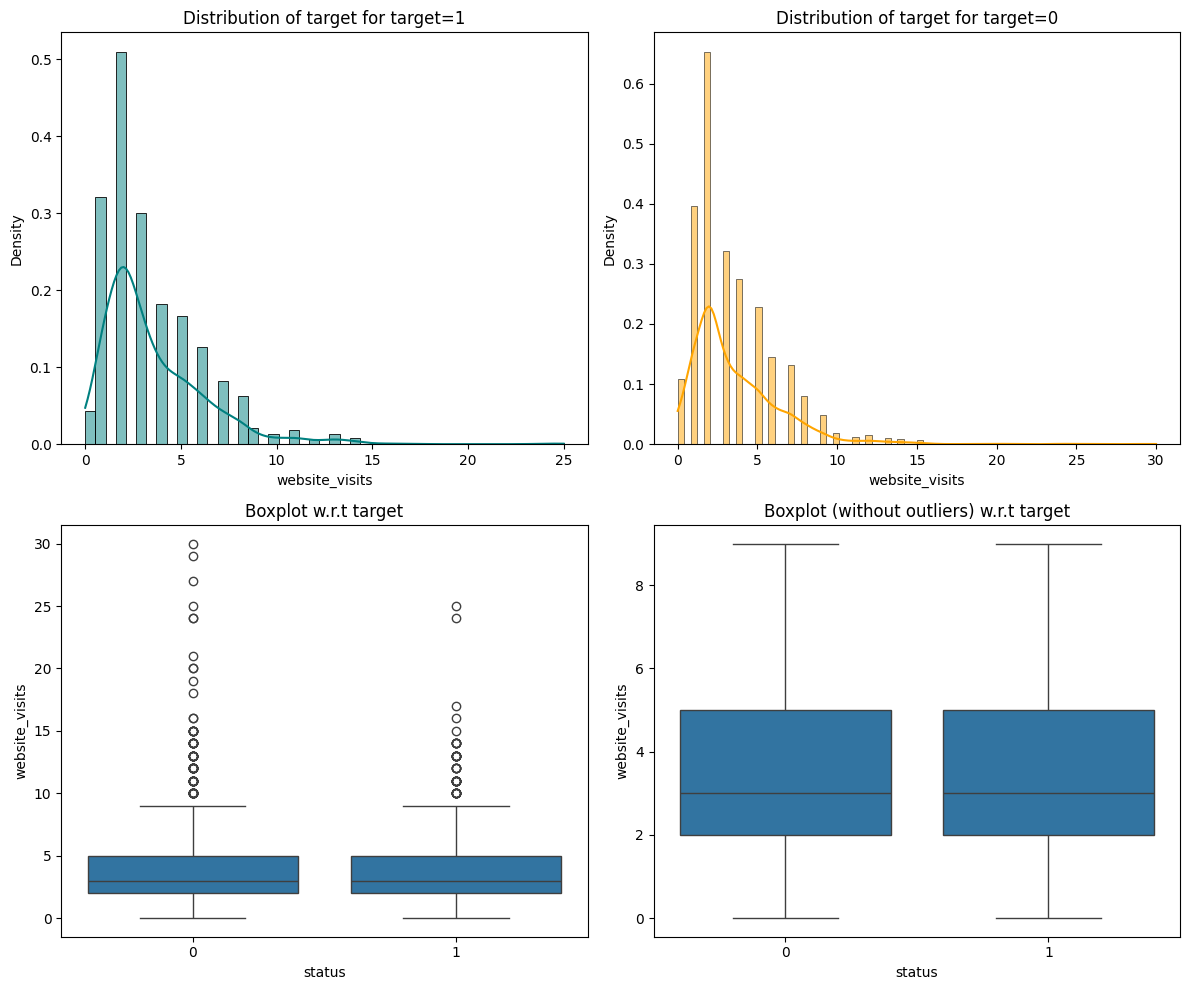

In [42]:
distribution_plot_wrt_target(data, "website_visits", "status") #distribution plot between website_visits and status

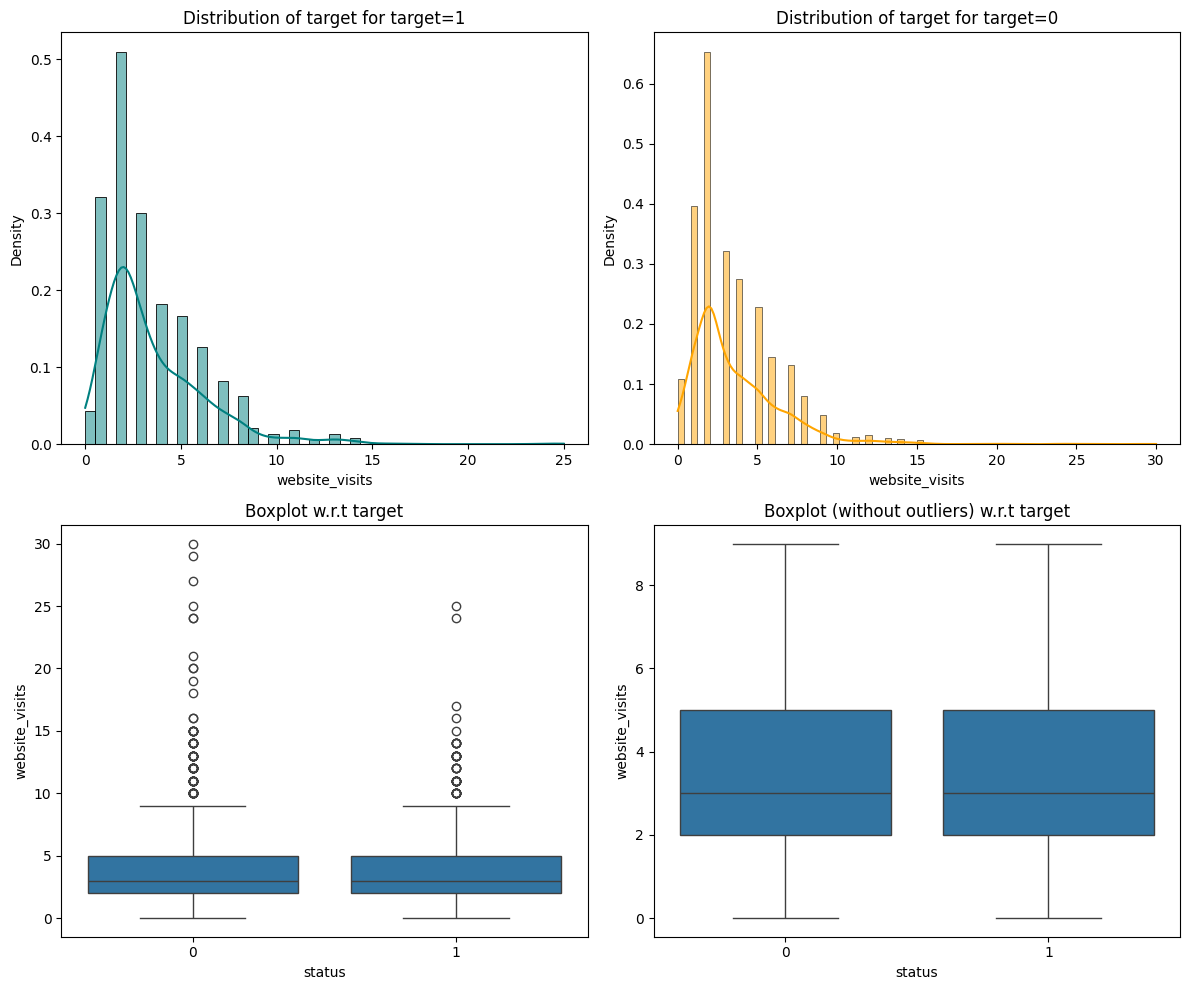

In [43]:
distribution_plot_wrt_target(data, "website_visits", "status") #distribution plot between website_visits and status

**People browsing the website or the mobile app are generally required to create a profile by sharing their personal details before they can access more information. Let's see if the profile completion level has an impact on lead status**

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


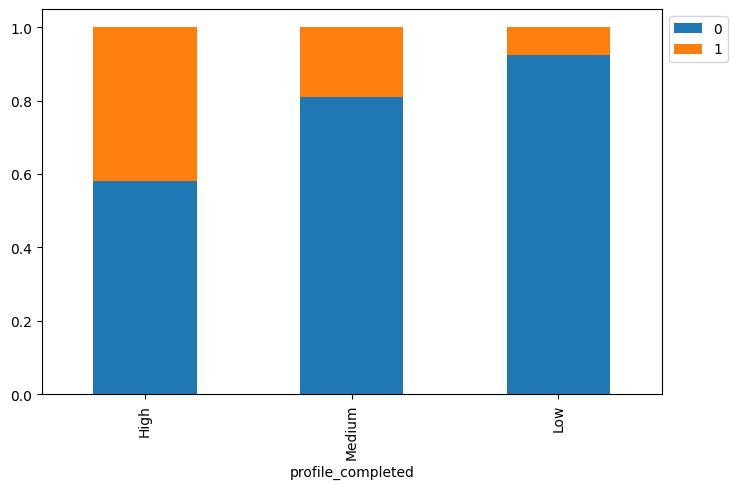

In [44]:
stacked_barplot(data, "profile_completed", "status")

**After a lead shares their information by creating a profile, there may be interactions between the lead and the company to proceed with the process of enrollment. Let's see how the last activity impacts lead conversion status**

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


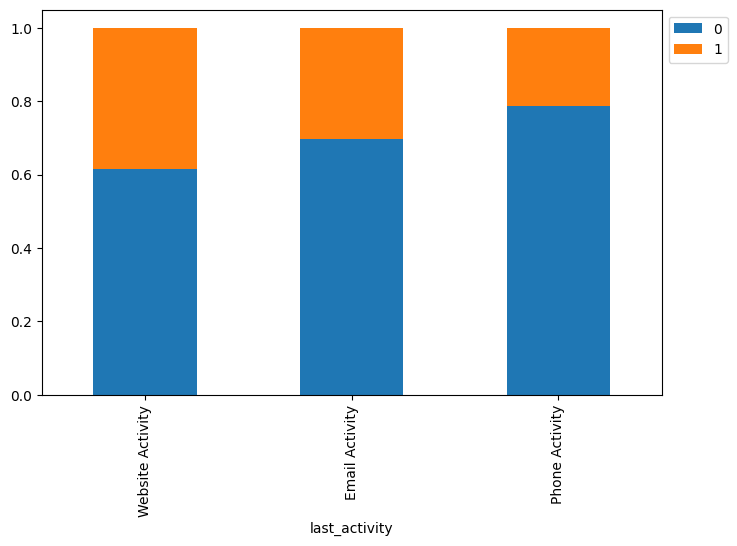

In [45]:
stacked_barplot(data, "last_activity", "status") #plot a stacked barplot between last_activity and status

**Let's see how advertisement and referrals impact the lead status**

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


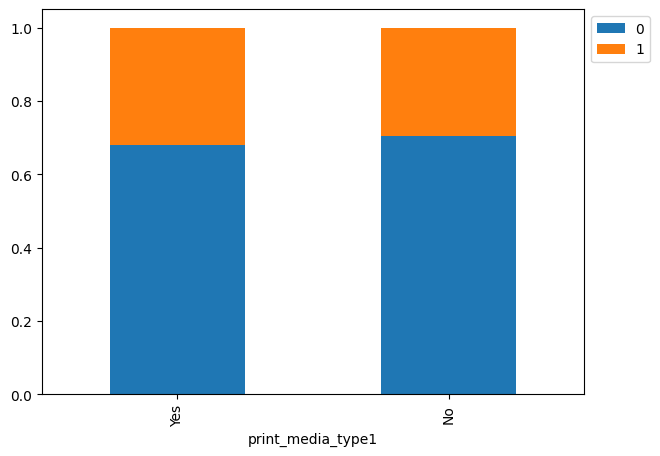

In [46]:
stacked_barplot(data, "print_media_type1", "status") #plot a stacked barplot between print_media_type1 and status

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


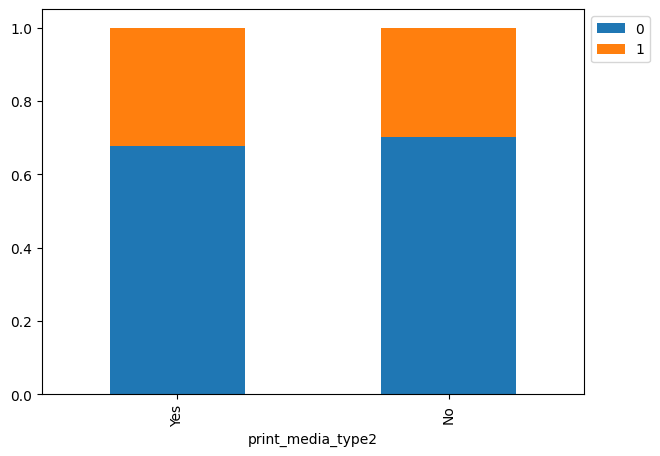

In [47]:
stacked_barplot(data, "print_media_type2", "status") #plot a stacked barplot between print_media_type2 and status

status            0     1   All
digital_media                  
All            3235  1377  4612
No             2876  1209  4085
Yes             359   168   527
------------------------------------------------------------------------------------------------------------------------


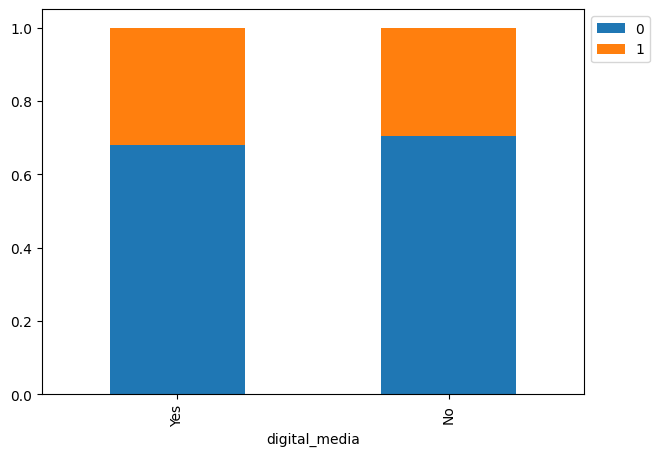

In [48]:
stacked_barplot(data, "digital_media", "status") #plot a stacked barplot between digital_media and status

status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


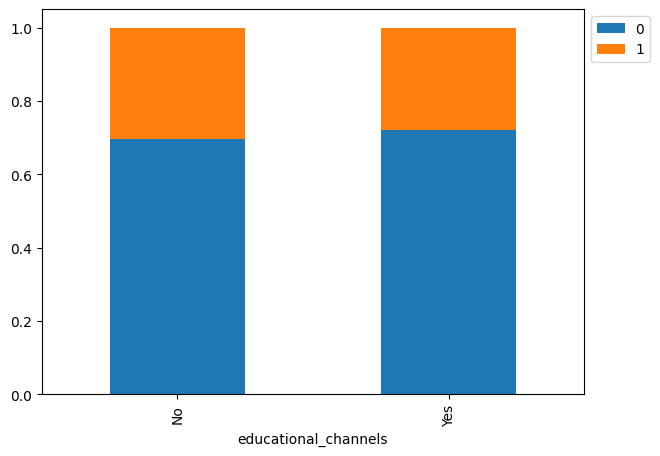

In [49]:
stacked_barplot(data, "educational_channels", "status") #plot a stacked barplot between educational_channels and status

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


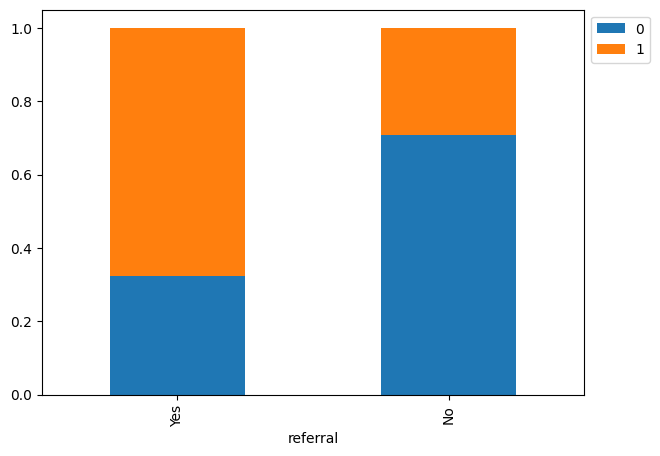

In [50]:
stacked_barplot(data, "referral", "status") #plot a stacked barplot between referral and status

# **Data Preprocessing**

## Outlier Check

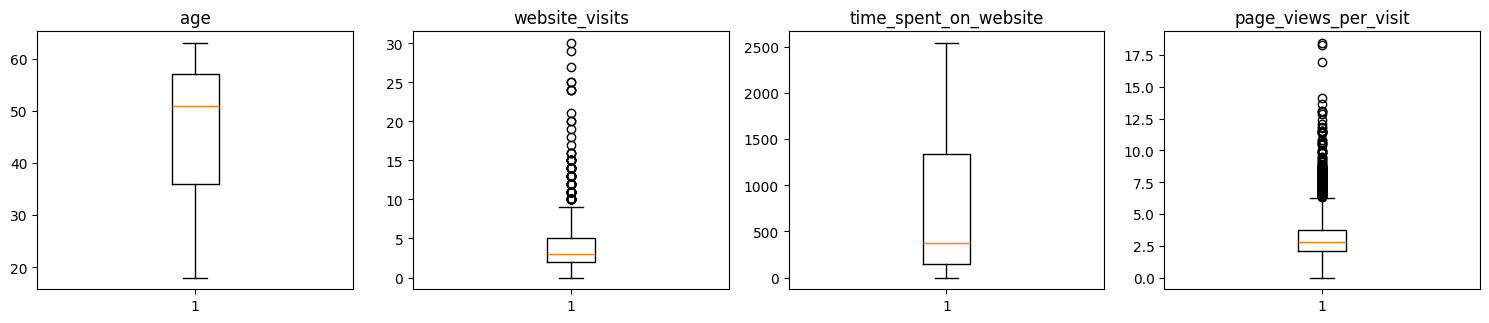

In [51]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a temporal variable
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## Data Preparation for modeling

- We want to predict which lead is more likely to be converted.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [53]:
X = data.drop(["status"], axis=1) #drop the status column
Y = data["status"]

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1 #define the test_size
)

In [54]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0    0.704151
1    0.295849
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0    0.695087
1    0.304913
Name: proportion, dtype: float64


## **Data Pre-processing Pipeline**

In [55]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['current_occupation',
 'first_interaction',
 'profile_completed',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral']

In [57]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Model Evaluation Criterion

- Mention the evaluation metric along with the reasoning

## Define functions for Model Evaluation

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and an appropriate evaluation metric to optimize the model.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [58]:
# Function to compute different metrics to check performance of a classification model
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classifier model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

## Random Forest Model

In [59]:
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator = make_pipeline(preprocessor,rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=1))])

### Checking model performance on training set

In [60]:
rf_estimator_model_train_perf = model_performance_classification(
    rf_estimator, X_train, y_train
)
rf_estimator_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.830235,0.645026,0.746667,0.692135


### Checking model performance on test set

In [61]:
rf_estimator_model_test_perf = model_performance_classification(
    rf_estimator, X_test, y_test
)
rf_estimator_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.787572,0.590047,0.672973,0.628788


## AdaBoost Classifier

In [62]:
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier = make_pipeline(preprocessor,ab_classifier)
ab_classifier.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('adaboostclassifier', AdaBoostClassifier(random_state=1))])

### Checking model performance on training set

In [63]:
ab_classifier_model_train_perf = model_performance_classification(
    ab_classifier, X_train, y_train
)
ab_classifier_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.813817,0.564398,0.744475,0.642049


### Checking model performance on test set

In [64]:
ab_classifier_model_test_perf = model_performance_classification(
    ab_classifier, X_test, y_test
)
ab_classifier_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.801301,0.549763,0.731861,0.627876


# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - Random Forest

In [120]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1)
rf_tuned = make_pipeline(preprocessor,rf_tuned)

# Grid of parameters to choose from
parameters = {
    "randomforestclassifier__max_depth": [5, 10, 15], #define the list of values for max_depth
    "randomforestclassifier__max_features": [0.7, 0.8], #define the list of values for max_features
    "randomforestclassifier__n_estimators": [100, 300, 500], #define the list of values for n_estimators
    "randomforestclassifier__class_weight": [None, "balanced"]
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=recall_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, max_features=0.7,
                                        random_state=1))])

### Checking model performance on training set

In [118]:
rf_tuned_model_train_perf = model_performance_classification(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.815675,0.590576,0.734375,0.654672


### Checking model performance on test set

In [119]:
rf_tuned_model_test_perf = model_performance_classification(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.796243,0.554502,0.713415,0.624


## Hyperparameter Tuning - AdaBoost Classifier

In [70]:
# Choose the type of classifier.
ab_tuned = AdaBoostClassifier(random_state=1)
ab_tuned = make_pipeline(preprocessor,ab_tuned)
# Grid of parameters to choose from

parameters = {
    "adaboostclassifier__n_estimators": [50, 100, 200], #define the list of values for n_estimators
    "adaboostclassifier__learning_rate": [0.1, 0.5, 1.0], #define the list of values for learning_rate
}


# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=recall_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('adaboostclassifier',
                 AdaBoostClassifier(learning_rate=0.1, random_state=1))])

### Checking model performance on training set

In [71]:
ab_tuned_model_train_perf = model_performance_classification(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.704151,0.0,0.0,0.0


### Checking model performance on test set

In [72]:
ab_tuned_model_test_perf = model_performance_classification(ab_tuned, X_test, y_test)
ab_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.704151,0.0,0.0,0.0


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [121]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_classifier_model_train_perf.T,
        ab_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Classifier",
    "Adaboost Tuned",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,Adaboost Classifier,Adaboost Tuned
Accuracy,0.830235,0.815675,0.813817,0.704151
Recall,0.645026,0.590576,0.564398,0.000000
Precision,0.746667,0.734375,0.744475,0.000000
F1,0.692135,0.654672,0.642049,0.000000


In [122]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_classifier_model_test_perf.T,
        ab_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Classifier",
    "Adaboost Tuned",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,Adaboost Classifier,Adaboost Tuned
Accuracy,0.787572,0.796243,0.801301,0.695087
Recall,0.590047,0.554502,0.549763,0.000000
Precision,0.672973,0.713415,0.731861,0.000000
F1,0.628788,0.624000,0.627876,0.000000


In [123]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [125]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/learn_model.joblib"

In [126]:
joblib.dump(rf_estimator, saved_model_path) #define the variable name of the best model. For eg, ab_tuned

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/learn_model.joblib


In [127]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/learn_model.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [128]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=1))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [129]:
saved_model.predict(X_test)

array([0, 0, 0, ..., 1, 0, 1])

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Flask Web Framework


In [130]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
learn_api = Flask("ExtraaLearn")

# Load the trained churn prediction model
model = joblib.load("learn_model.joblib")

# Define a route for the home page
@learn_api.get('/')
def home():
    return "Welcome to the Lead Prediction System"

# Define an endpoint to predict churn for a single customer
@learn_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant customer features from the input data
    sample = {
    'age': data['age'],
    'current_occupation': data['current_occupation'],
    'first_interaction': data['first_interaction'],
    'profile_completed': data['profile_completed'],
    'website_visits': data['website_visits'],
    'time_spent_on_website': data['time_spent_on_website'],
    'page_views_per_visit': data['page_views_per_visit'],
    'last_activity': data['last_activity'],
    'print_media_type1': data['print_media_type1'],
    'print_media_type2': data['print_media_type2'],
    'digital_media': data['digital_media'],
    'educational_channels': data['educational_channels'],
    'referral': data['referral']
}


    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Lead': prediction})

Overwriting backend_files/app.py


## Dependencies File

In [131]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
uvicorn[standard]
streamlit==1.43.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [132]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:learn_api"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

**Note**: We are creating a Hugging Face Docker Space for our backend using the Hugging Face Hub API. This automates the space creation process and enables seamless deployment of our Flask app.

In [ ]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to your Hugging Face account using your access token
# Replace "YOUR_HUGGINGFACE_TOKEN" with your actual token
#login(token="YOUR_HUGGINGFACE_TOKEN")  # You can get your token from https://huggingface.co/settings/tokens
login(token="") #define your Hugging Face access token

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

**Note :** If you were trying with different names, be cautious when using a underscore `_` in space names, such as `frontend_space`, as it can cause exceptions when accessing the API. Always use an hyphen `-` instead, like `frontend-space`.

In [134]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("extralearn",  #define the name of your Hugging Face space
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-6a243d6b-4b2b98a35ba88de443dc1ce6;33670264-7a7d-490a-a4d0-f0fa423ddd41)

You already created this space repo: dcsamuel/extralearn


## Uploading Files to Hugging Face Space (Docker Space)

**Note**: Before running the code below, ensure that the serialized ML model has been uploaded in to `backend_files` folder.

In [ ]:
# for hugging face space authentication to upload files

access_key = ""  # define your Hugging Face access token
repo_id = "repo"  #define your Hugging Face repo_id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="backend_files",  # Local folder path in azureml
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Uploading...:   0%|          | 0.00/3.59M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/spaces/dcsamuel/extralearn/commit/2289e826412ab85055500b5ea537f9b9c37e0780', commit_message='Upload folder using huggingface_hub', commit_description='', oid='2289e826412ab85055500b5ea537f9b9c37e0780', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/dcsamuel/extralearn', endpoint='https://huggingface.co', repo_type='space', repo_id='dcsamuel/extralearn'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [111]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py

import streamlit as st
import requests

st.set_page_config(page_title="ExtraaLearn Lead Conversion Predictor", page_icon="💡", layout="centered")

st.header("Lead Conversion Prediction System")
st.markdown("Enter the lead's information below to predict their conversion likelihood.")

st.subheader("Personal Information")
age = st.number_input("Age", min_value=0, value=25)
current_occupation = st.selectbox("Current Occupation", ["Professional", "Unemployed", "Student"])

st.subheader("Interaction Details")
first_interaction = st.selectbox("First Interaction Platform", ["Website", "Mobile App"])
profile_completed = st.selectbox("Profile Completion Level", ["Low", "Medium", "High"])
website_visits = st.number_input("Number of Website Visits", min_value=0, value=3)
time_spent_on_website = st.number_input("Time Spent on Website (in seconds)", min_value=0.0, value=180.0)
page_views_per_visit = st.number_input("Page Views per Visit", min_value=0.0, value=4.5)
last_activity = st.selectbox("Last Activity Type", ["Email Activity", "Phone Activity", "Website Activity"])

st.subheader("Referral and Media Exposure")
print_media_type1 = st.selectbox("Seen Newspaper Ad?", ["Yes", "No"])
print_media_type2 = st.selectbox("Seen Magazine Ad?", ["Yes", "No"])
digital_media = st.selectbox("Seen Digital Media Ad?", ["Yes", "No"])
educational_channels = st.selectbox("Heard via Educational Channels?", ["Yes", "No"])
referral = st.selectbox("Heard via Referral?", ["Yes", "No"])


lead_data = {
    "age": age,
    "current_occupation": current_occupation,
    "first_interaction": first_interaction,
    "profile_completed": profile_completed,
    "website_visits": website_visits,
    "time_spent_on_website": time_spent_on_website,
    "page_views_per_visit": page_views_per_visit,
    "last_activity": last_activity,
    "print_media_type1": print_media_type1,
    "print_media_type2": print_media_type2,
    "digital_media": digital_media,
    "educational_channels": educational_channels,
    "referral": referral
}


if st.button("Predict", type='primary'):
    #Format : https://<Hugging Face Space name>.hf.space/v1/predict
    response = requests.post("urspace/v1/predict", json=lead_data)
    if response.status_code == 200:
        result = response.json()
        predicted_value = result["Lead"]
        if predicted_value == 1:
            st.success("Predicted: Lead will be converted to Customer (1)")
        else:
            st.info("Predicted: Lead will not be converted to Customer (0)")
    else:
        st.error("Error in API request")

Overwriting frontend_files/app.py


## Dependencies File

In [138]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

Overwriting frontend_files/requirements.txt


## Dockerfile

In [139]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [142]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("extralearnview",  #define the name of your Hugging Face space
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-6a243f20-79b4ed244ab26b1754c42c69;7faea8d5-b854-4a00-918c-86ecd509e08a)

You already created this space repo: dcsamuel/extralearnview


In [ ]:
access_key = ""  #define your Hugging Face access token
repo_id = "repo/extralearnview"  #define your Hugging Face repo_id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="frontend_files",  # Local folder path in azureml
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/dcsamuel/extralearnview/commit/bbf7e69afa5b403d2fa8f7b483f3b93041b44d59', commit_message='Upload folder using huggingface_hub', commit_description='', oid='bbf7e69afa5b403d2fa8f7b483f3b93041b44d59', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/dcsamuel/extralearnview', endpoint='https://huggingface.co', repo_type='space', repo_id='dcsamuel/extralearnview'), pr_revision=None, pr_num=None)

# **Actionable Insights and Business Recommendations**

## Project Summary

This project aimed to analyze and build a machine learning model to identify which leads are more likely to convert to paid customers for ExtraaLearn. The dataset contained various attributes of leads, including their demographics, interaction details, and conversion status.

### Key Steps:

1.  **Data Loading and Preprocessing**: The dataset was loaded, duplicates were checked, and the 'ID' column was dropped. Categorical features were identified for one-hot encoding.
2.  **Exploratory Data Analysis (EDA)**: Univariate and bivariate analyses were performed to understand data distributions, relationships between variables, and the impact of different features on lead conversion. Key observations were made regarding age, website visits, time spent on the website, first interaction, profile completion, last activity, and media types.
3.  **Model Building**:
    *   The data was split into training and testing sets (70:30 ratio).
    *   Random Forest and AdaBoost classifiers were trained, both as base models and with hyperparameter tuning using `GridSearchCV`.
    *   The `recall_score` was chosen as the primary evaluation metric due to the business objective of minimizing false negatives (i.e., not missing potential conversions).
4.  **Model Evaluation and Selection**:
    *   The Random Forest Tuned model (`rf_tuned`) demonstrated the best performance, achieving a recall of **0.5545** on the test set, significantly outperforming the AdaBoost Tuned model (which had a recall of 0.0).
    *   The `rf_tuned` model was selected as the final model due to its balanced performance, especially in identifying positive conversions.
5.  **Model Serialization and Deployment**:
    *   The best performing model (`rf_tuned`) was serialized using `joblib`.
    *   A Flask API was created (`app.py`), along with dependency (`requirements.txt`) and Dockerfile configurations, to serve the model predictions.
    *   Both the backend (Flask API) and a frontend (Streamlit application) were successfully deployed to Hugging Face Spaces using `huggingface_hub` for seamless interaction.

## Actionable Insights

1.  **Professionals show higher conversion rates**: Leads with 'Professional' occupation have a significantly higher conversion rate compared to 'Unemployed' or 'Student' leads. This suggests that marketing efforts might yield better results when targeted towards this group.
2.  **Website-initiated interactions are crucial**: Leads whose first interaction was through the 'Website' convert at a much higher rate (around 45%) than those from 'Mobile App' (around 10%). This highlights the importance of optimizing the website experience and potentially re-evaluating the mobile app's initial engagement strategy.
3.  **Time spent on the website correlates with conversion**: Converted leads tend to spend more time on the website (median of 789 seconds) compared to non-converted leads (median of 317 seconds). This suggests that engaging content and a user-friendly website experience are key.
4.  **Profile completion matters**: Leads who complete a 'High' percentage of their profile have a higher conversion rate than those with 'Medium' or 'Low' completion. This indicates that leads willing to provide more information are more serious about the offerings.
5.  **Email and Website Activity are effective 'Last Activities'**: 'Email Activity' and 'Website Activity' as the last interaction show higher conversion probabilities than 'Phone Activity'. This implies that digital, self-paced engagement methods are more effective in nurturing leads.
6.  **Referrals are highly effective**: Although the volume is low, leads from 'Referral' sources have a substantially higher conversion rate compared to other channels, indicating a strong trust factor.
7.  **Advertisements have limited direct impact**: While various media types (print, digital) contribute to lead generation, their direct impact on conversion rates is less pronounced compared to engagement metrics like time on website or profile completion. Educational channels show a slightly better conversion rate than other media types.

## Business Recommendations

Based on the analysis, here are some recommendations for ExtraaLearn:

1.  **Prioritize and Segment Leads**: Implement a lead scoring system based on the insights from the model. Leads identified as 'Professional' with 'Website' as their first interaction, higher 'time_spent_on_website', and 'High' profile completion should be prioritized for immediate follow-up by sales teams.
2.  **Optimize Website Experience**: Invest further in website content, user experience (UX), and interactive features to encourage longer engagement. Implement clear calls to action and easy navigation to guide users towards profile completion.
3.  **Enhance Email and Website Engagement Strategies**: Focus nurturing efforts on email campaigns and website interactions. Develop targeted email sequences with valuable content (e.g., success stories, course previews, expert webinars) and personalize website content based on user behavior.
4.  **Refine Mobile App Strategy**: Investigate the lower conversion rate from mobile app first interactions. This could involve improving the app's onboarding process, ensuring content parity with the website, or offering exclusive mobile app benefits to drive deeper engagement.
5.  **Leverage Referral Programs**: Design and promote robust referral programs to capitalize on the high conversion rate from referred leads. Offer incentives for both referrers and referred individuals.
6.  **Review Sales Process for Phone Activity**: Analyze the 'Phone Activity' process to identify bottlenecks or areas for improvement, as it shows a lower conversion rate compared to other last activities. This could involve training sales representatives on more effective communication strategies or providing more personalized information during calls.
7.  **Iterative Model Improvement**: Continuously monitor the model's performance in production. Collect new data, retrain the model periodically, and re-evaluate feature importance to adapt to changing lead behavior and market dynamics. Regular A/B testing of different lead nurturing strategies informed by model insights can further optimize conversion.

#<font size=6 color='blue'>Power Ahead</font>
___